In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from scipy import stats 
import re

In [2]:
### Import pre-formated data 

results_dir = Path('final_results_dir')

# diotic SWC 
diotic_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_SWC_diotic_conditions_humans_N-195_models_v10_w_control_archs_and_50Hz.pdpkl")
diotic_results['experiment'] = 'Diotic'

# Popham SWC
popham_results = pd.read_pickle(results_dir / "df_for_stats_2024_SWC_popham_conditions_humans_N-90_models_v10_w_control_archs_w_50Hz.pdpkl")
popham_results.loc[popham_results.group.str.contains("Human"), 'model'] = popham_results.loc[popham_results.group.str.contains("Human"), 'group']
popham_results['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

popham_results = popham_results[popham_results['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)
popham_results['experiment'] = 'Harmonicity'

# threshold results 
threshold_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_thresholds_humans_N-33_models_v10_w_control_archs_w50Hz.pdpkl")
threshold_results['background_condition'] = threshold_results['azim_delta'].astype('str') + ' azim delta ' + threshold_results['elev_delta'].astype('str') + ' elev delta' 
threshold_results['experiment'] = 'Threshold'
threshold_results.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)

# Spotlight results 
spotlight_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_spotlight_humans_N-28_models_v10_w_control_archs_w50Hz.pdpkl")
spotlight_results['snr'] = 0 
spotlight_results['background_condition'] = spotlight_results['target_azim'].astype('str') + ' target azim ' + spotlight_results['azim_delta'].astype('str') + ' azim delta'
spotlight_results['experiment'] = 'Spotlight'
spotlight_results.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)


In [3]:
combined_results = pd.concat([diotic_results, popham_results, threshold_results, spotlight_results], axis=0)
## update model names for comparison 

combined_results.loc[combined_results['model'].str.contains("early"), 'model'] = 'Early-only'
combined_results.loc[combined_results['model'].str.contains("late"), 'model'] = 'Late-only'
combined_results.loc[combined_results['model'].str.contains("control"), 'model'] = 'Baseline CNN'

combined_results['model'] = combined_results['model'].apply(util_analysis.get_model_name)
combined_results.loc[combined_results['model'] == "50Hz cutoff", "group"] = "50Hz cutoff"

combined_results = combined_results[combined_results['model'] != "Computed-gain model"].reset_index(drop=True)


In [4]:
combined_results.model.value_counts()

model
Feature-gain alt v9     100
Baseline CNN            100
Feature-gain alt v10    100
Feature-gain alt v12    100
Feature-gain alt v2     100
Feature-gain alt v4     100
Feature-gain alt v6     100
Feature-gain alt v7     100
Feature-gain alt v8     100
Feature-gain alt v1     100
Feature-gain main       100
Early-only              100
50Hz cutoff             100
Late-only               100
Human (N=195)            56
Human (N=33)             30
Humans (N=28)             8
Humans (N = 90)           6
Name: count, dtype: int64

In [5]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.model.unique() if 'Human' not in model]


model_sim_records = []

for ix, model in enumerate(model_list):
    # if model == 'Feature-gain Model':
    #     fba_to_plot = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
    #     fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
    #     fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

    #     fba_to_plot['group'] = 'Feature-gain model'
    #     model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    # else:
    model_results = combined_results[combined_results.model == model]
    model_results = model_results.sort_values(['snr', 'background_condition'])

    # get missing snr x background conditions 
    # model_conds = model_results.snr_condition_str.unique()
    # human_conds = human_results.snr_condition_str.unique()
    # conds_to_keep = human_conds[np.isin(human_conds, model_conds)]

    # human_to_plot = human_results[human_results.snr_condition_str.isin(conds_to_keep)].copy()
    # model_to_plot = model_results[model_results.snr_condition_str.isin(conds_to_keep)].copy()
    


    ## Add stats 
    r, p = stats.pearsonr(human_results.accuracy,  model_results.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_r = r ** 2 
    # add to dict 
    acc_rmse = np.sqrt(np.mean((human_results.accuracy.values - model_results.accuracy.values)**2))

    # conf errors
    r, p = stats.pearsonr(human_results.confusions, model_results.confusions)
    conf_r = r ** 2
    conf_rmse = np.sqrt(np.mean((human_results.confusions.values - model_results.confusions.values)**2))

    record = {'model': model, 'acc_r': acc_r, 'acc_rmse': acc_rmse, 'conf_r': conf_r, 'conf_rmse': conf_rmse}
    model_sim_records.append(record)


In [6]:
model_sim_df = pd.DataFrame.from_records(model_sim_records)

In [7]:
model

'Baseline CNN'

In [8]:
model

'Baseline CNN'

In [9]:
# sign test
# from statsmodels.stats.descriptivestats import sign_test

def sign_test(x, mu0):
    n = len(x)
    n_pos = np.sum(x > mu0)
    n_neg = np.sum(x < mu0)
    effect_m = (n_pos - n_neg) / 2 
    p = stats.binomtest(min(n_pos, n_neg), n, p=0.5).pvalue
    return effect_m, p

# run sign test per alternate model 
fba_model_r_acc_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|gain"), "acc_r"].values
fba_model_r_conf_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|gain"), "conf_r"].values
for model in ["Early-only", "Late-only", "Baseline CNN", "50Hz cutoff"]:
    y_acc = model_sim_df.loc[model_sim_df.model == model, "acc_r"].values
    stats_result = sign_test(fba_model_r_acc_dist, mu0=y_acc)
    print(f"Feature-gain v {model}, Pearson's r^2 accuracy sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    y_conf = model_sim_df.loc[model_sim_df.model == model, "conf_r"].values
    stats_result = sign_test(fba_model_r_conf_dist, mu0=y_conf)
    print(f"Feature-gain v {model}, Pearson's r^2 confusions sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    print("")   

# fba_model_r_acc_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|arch"), "acc_rmse"].values
# for model in ["Early-only", "Late-only", "Baseline CNN"]:
#     y = model_sim_df.loc[model_sim_df.model == model, "acc_rmse"].values
#     stats_result = sign_test(fba_model_r_acc_dist, mu0=y)
#     print(f"Feature-gain v  {model}, RMSE similarity sign test p={stats_result:.5f}")

fba_model_r_acc_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|gain"), "acc_rmse"].values
fba_model_r_conf_dist = model_sim_df.loc[model_sim_df.model.str.contains("main|gain"), "conf_rmse"].values
for model in ["Early-only", "Late-only", "Baseline CNN", "50Hz cutoff"]:
    y_acc = model_sim_df.loc[model_sim_df.model == model, "acc_rmse"].values
    stats_result = sign_test(fba_model_r_acc_dist, mu0=y_acc)
    print(f"Feature-gain v {model}, RMSE accuracy sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    y_conf = model_sim_df.loc[model_sim_df.model == model, "conf_rmse"].values
    stats_result = sign_test(fba_model_r_conf_dist, mu0=y_conf)
    print(f"Feature-gain v {model}, RMSE confusions sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    print("")   


Feature-gain v Early-only, Pearson's r^2 accuracy sign test stat=5.0 p=0.00195
Feature-gain v Early-only, Pearson's r^2 confusions sign test stat=-5.0 p=0.00195

Feature-gain v Late-only, Pearson's r^2 accuracy sign test stat=5.0 p=0.00195
Feature-gain v Late-only, Pearson's r^2 confusions sign test stat=5.0 p=0.00195

Feature-gain v Baseline CNN, Pearson's r^2 accuracy sign test stat=5.0 p=0.00195
Feature-gain v Baseline CNN, Pearson's r^2 confusions sign test stat=2.0 p=0.34375

Feature-gain v 50Hz cutoff, Pearson's r^2 accuracy sign test stat=-3.0 p=0.10938
Feature-gain v 50Hz cutoff, Pearson's r^2 confusions sign test stat=-5.0 p=0.00195

Feature-gain v Early-only, RMSE accuracy sign test stat=-5.0 p=0.00195
Feature-gain v Early-only, RMSE confusions sign test stat=5.0 p=0.00195

Feature-gain v Late-only, RMSE accuracy sign test stat=-5.0 p=0.00195
Feature-gain v Late-only, RMSE confusions sign test stat=-5.0 p=0.00195

Feature-gain v Baseline CNN, RMSE accuracy sign test stat=-5.0

In [10]:
combined_results.group.unique()

array(['Human (N=195)', 'Feature-gain Model', 'Early-only', '50Hz cutoff',
       'Late-only', 'Baseline CNN', 'Humans (N = 90)', 'Human (N=33)',
       'Humans (N=28)'], dtype=object)

In [11]:
model

'50Hz cutoff'

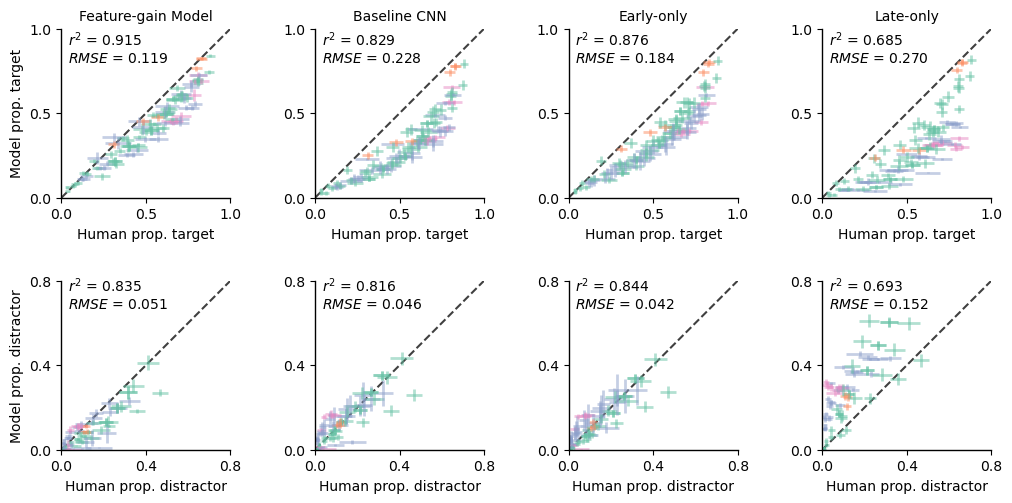

In [12]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

# model_list = [model for model in combined_results.group.unique() if 'Human' not in model]
model_order = util_analysis.model_name_order


model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM

fig, axs = plt.subplots(2, len(model_order), 
                        figsize=((aspect * len(model_order)),
                        aspect*2))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_order)):
        if j != len(model_order):
            axs[i,j].plot(x,y, ls='dashed', color='k', alpha=0.75)


vert_spacing = 0.1 
conf_max_y = 0.8



## Get color palette per experiment 
experiment_colors = [
    'Diotic',
    'Harmonicity',
    'Threshold',
    'Spotlight'
]

# get 4 colors from Set2 palette
cmap = sns.color_palette("Set2", n_colors=4)

color_dict = {experiment:cmap[ix] for  ix,experiment in enumerate(experiment_colors)}
colors = [color_dict[experiment] for experiment in human_results.experiment.values]



model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_order):
    if model == 'Feature-gain Model':
        fba_to_plot = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
        fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
        fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

        fba_to_plot['group'] = 'Feature-gain Model'
        model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    else:
        model_results = combined_results[combined_results.model == model]
        model_results = model_results.sort_values(['snr', 'background_condition'])

    acc_axs[ix].errorbar(x=human_results.accuracy, y=model_results.accuracy,
                          xerr=human_results.acc_sem * sem_order,
                         yerr=model_results.acc_sem * sem_order, 
                         marker='', alpha=0.5,
                        ecolor=colors,
                linestyle='', ms=3, elinewidth=line_width,)
    
    conf_axs[ix].errorbar(x=human_results.confusions, y=model_results.confusions,
                          xerr=human_results.conf_sem * sem_order,
                          yerr=model_results.conf_sem * sem_order,
                            marker='', alpha=0.5,
                            ecolor=colors,
                linestyle='', ms=3, elinewidth=line_width,)
    
    acc_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_results.accuracy,  model_results.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_axs[ix].annotate(f"$r^2$ = {r**2:.3f}", (0.04, 0.9), fontsize=fontsize)

    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_results.accuracy.values - model_results.accuracy.values)**2))
    acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.3f}", (0.04, 0.8), fontsize=fontsize)
    model_r2_dict[model]['accuracy'] = r**2
    model_rmse_dict[model]['accuracy'] = samp_rmse

    # conf errors
    r, p = stats.pearsonr(human_results.confusions, model_results.confusions)
    conf_axs[ix].annotate(f"$r^2$ = {r**2:.3f}", (0.032, 0.75), fontsize=fontsize) 
    samp_rmse = np.sqrt(np.mean((human_results.confusions.values - model_results.confusions.values)**2))

    conf_rmse_y = 0.75 - (vert_spacing * conf_max_y)
    conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.3f}", (0.032, conf_rmse_y), fontsize=fontsize) # old xy coords (0.25, 0.025)
    model_r2_dict[model]['confusions'] = r**2
    model_rmse_dict[model]['confusions'] = samp_rmse
    

    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

In [13]:
# y = fba_to_plot.accuracy.values
# x = np.arange(len(y))
# plt.bar(x,y)
# y = fba_to_plot.accuracy.values
# plt.bar(x,model_to_plot.accuracy.values)

## Plot each feature-gain arch separately 

### Plot accuracy first

In [14]:
model

'Late-only'

In [15]:
def pearsons_r(vec_a, vec_b):
    """
    Calculate Pearson's r correlation coefficient between two vectors.
    """
    n = len(vec_a)
    mean_a = np.mean(vec_a)
    mean_b = np.mean(vec_b)
    ss_a = np.sum((vec_a - mean_a) ** 2)
    ss_b = np.sum((vec_b - mean_b) ** 2)
    cov_ab = np.sum((vec_a - mean_a) * (vec_b - mean_b))
    r = cov_ab / np.sqrt(ss_a * ss_b)
    return r

In [16]:
util_analysis.model_name_order_w_50Hz

['Feature-gain Model',
 'Baseline CNN',
 'Early-only',
 'Late-only',
 '50Hz cutoff']

In [17]:
model_list = [model for model in combined_results.model.unique() if ('Human' not in model) and ('50Hz' not in model)]
model_list

['Feature-gain alt v1',
 'Feature-gain alt v10',
 'Feature-gain alt v12',
 'Feature-gain alt v2',
 'Feature-gain alt v4',
 'Feature-gain alt v6',
 'Feature-gain alt v7',
 'Feature-gain alt v8',
 'Feature-gain alt v9',
 'Feature-gain main',
 'Early-only',
 'Late-only',
 'Baseline CNN']

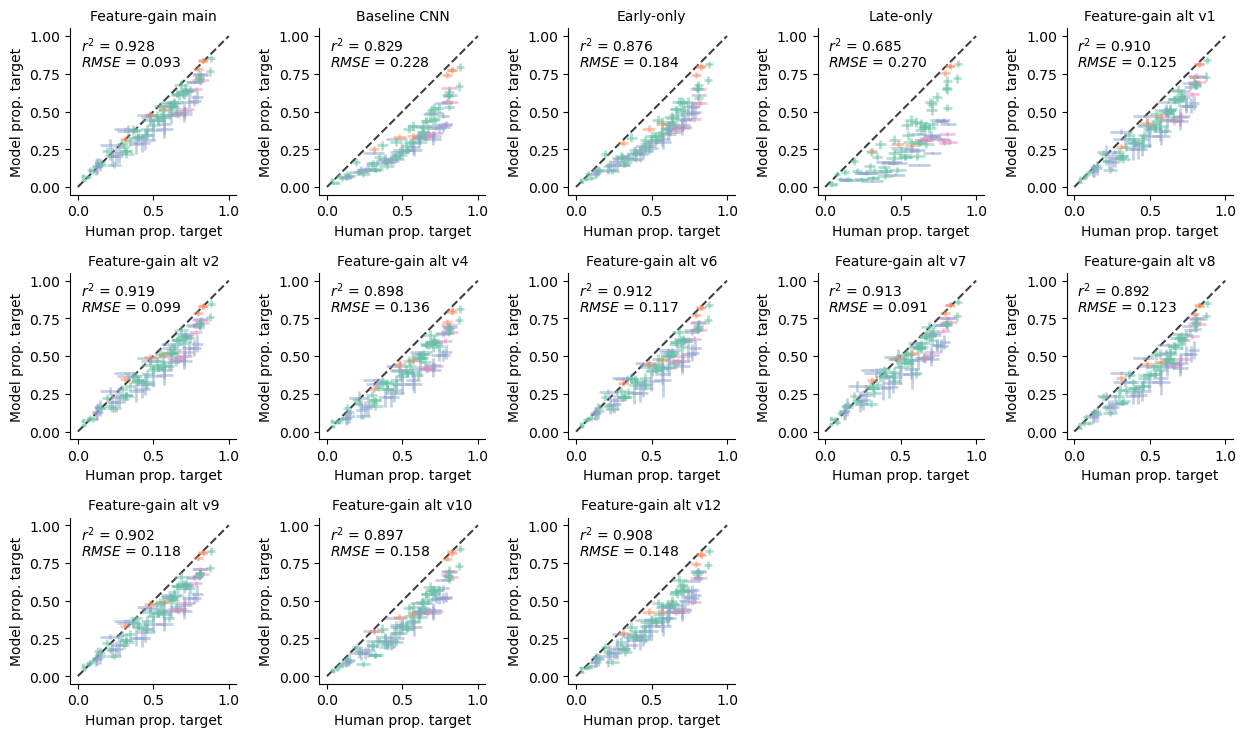

In [18]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.model.unique() if ('Human' not in model) and ('50Hz' not in model)]
n_models = len(model_list)

model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM
n_cols = 5
n_rows = (n_models // n_cols) + 1

fig, axs = plt.subplots(n_rows, n_cols, 
                        figsize=((aspect * n_cols),
                        aspect*n_rows))
axs = axs.flatten()

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs:
    ax.plot(x,y, ls='dashed', color='k', alpha=0.75)


# add markers to relplot
model_order = [
                'Feature-gain main',
                'Baseline CNN',
                'Early-only',
                'Late-only',
                # "50Hz cutoff"
                ]

also_sort = [m for m in model_list if m not in model_order]
model_order += sorted(also_sort, key=lambda x: int(re.search(r'\d+', x).group()))

## Get color palette per experiment 
experiment_colors = [
    'Diotic',
    'Harmonicity',
    'Threshold',
    'Spotlight'
]

# get 4 colors from Set2 palette
cmap = sns.color_palette("Set2", n_colors=4)

color_dict = {experiment:cmap[ix] for  ix,experiment in enumerate(experiment_colors)}
colors = [color_dict[experiment] for experiment in human_results.experiment.values]



vert_spacing = 0.1 
conf_max_y = 0.8

model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_order):

    model_results = combined_results[combined_results.model == model]
    model_results = model_results.sort_values(['snr', 'background_condition'])
    axs[ix].errorbar(x=human_results.accuracy, y=model_results.accuracy,
                          xerr=human_results.acc_sem * sem_order,
                         yerr=model_results.acc_sem * sem_order, 
                         marker='', alpha=0.5,
                        ecolor=colors,
                linestyle='', ms=3, elinewidth=line_width,)
    

    axs[ix].set_title(util_analysis.get_model_name(model), fontsize=fontsize)
    axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    axs[ix].set_ylabel(f"Model prop. target", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_results.accuracy,  model_results.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    axs[ix].annotate(f"$r^2$ = {r**2:.3f}", (0.02, 0.9), fontsize=fontsize)
    # manual_r = pearsons_r(human_results.accuracy.values,  model_results.accuracy.values)

    # axs[ix].annotate(f"manual $r$ = {manual_r:.3f}", (0.05, 1), fontsize=fontsize)
    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_results.accuracy.values - model_results.accuracy.values)**2))
    axs[ix].annotate(f"$RMSE$ = {samp_rmse:.3f}", (0.02, 0.8), fontsize=fontsize)
    model_r2_dict[model]['accuracy'] = r**2
    model_rmse_dict[model]['accuracy'] = samp_rmse


    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ix, ax in enumerate(axs.flat):
    ax.set(aspect='equal')
    if ix >= n_models:
        # remove panel
        ax.set_visible(False)


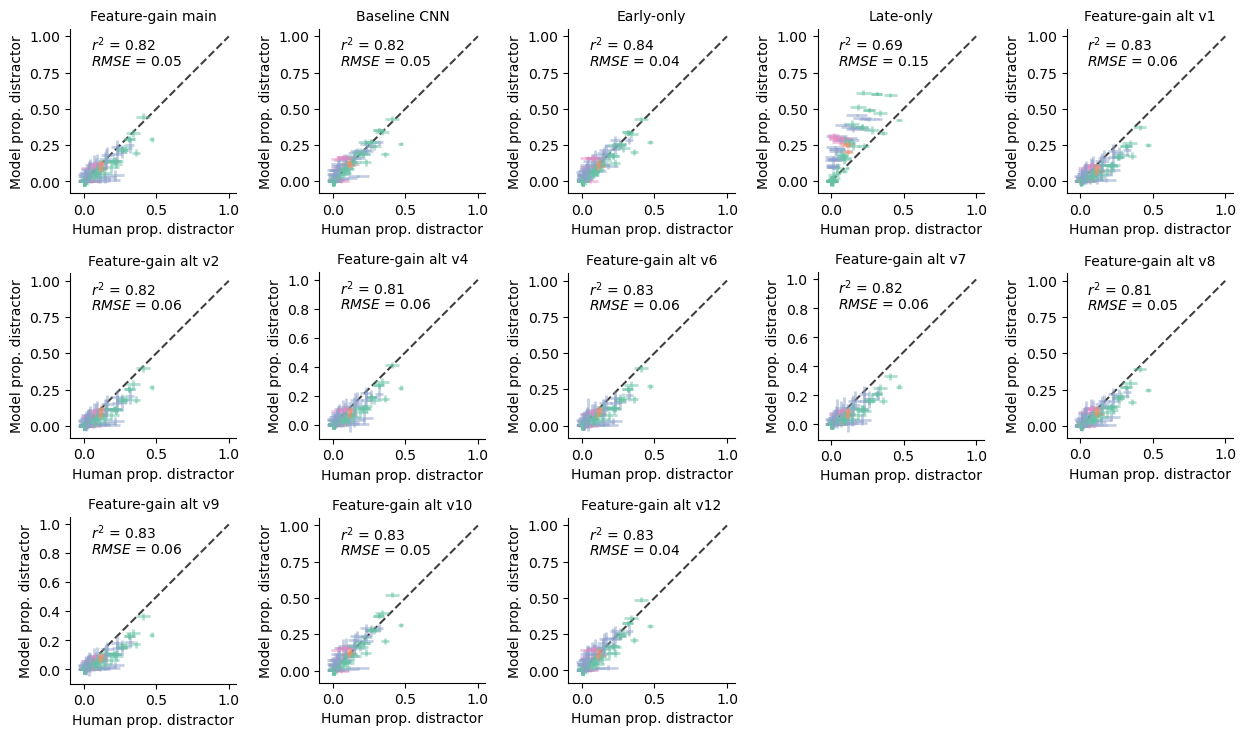

In [19]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.model.unique() if ('Human' not in model) and ('50Hz' not in model)]
n_models = len(model_list)

model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM
n_cols = 5
n_rows = (n_models // n_cols) + 1

fig, axs = plt.subplots(n_rows, n_cols, 
                        figsize=((aspect * n_cols),
                        aspect*n_rows))
axs = axs.flatten()

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs:
    ax.plot(x,y, ls='dashed', color='k', alpha=0.75)


# add markers to relplot
model_order = [
                'Feature-gain main',
                'Baseline CNN',
                'Early-only',
                'Late-only',
                # "50Hz cutoff"
                ]
                
also_sort = [m for m in model_list if m not in model_order]
model_order += sorted(also_sort, key=lambda x: int(re.search(r'\d+', x).group()))



vert_spacing = 0.1 
conf_max_y = 0.8

model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_order):

    model_results = combined_results[combined_results.model == model]
    model_results = model_results.sort_values(['snr', 'background_condition'])
    axs[ix].errorbar(x=human_results.confusions, y=model_results.confusions,
                          xerr=human_results.acc_sem * sem_order,
                         yerr=model_results.acc_sem * sem_order, 
                         marker='', alpha=0.5,
                        ecolor=colors,
                linestyle='', ms=3, elinewidth=line_width,)
    

    axs[ix].set_title(util_analysis.get_model_name(model), fontsize=fontsize)
    axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)
    axs[ix].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_results.confusions,  model_results.confusions)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    axs[ix].annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.9), fontsize=fontsize)

    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_results.confusions.values - model_results.confusions.values)**2))
    axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.05, 0.8), fontsize=fontsize)
    model_r2_dict[model]['confusions'] = r**2
    model_rmse_dict[model]['confusions'] = samp_rmse


    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ix, ax in enumerate(axs.flat):
    ax.set(aspect='equal')
    if ix >= n_models:
        # remove panel
        ax.set_visible(False)


## Plot aggrigate summary 

## Plot bar chart, pooling accuracy and confusions

### Run sign test on pooled similarity scores (pool hits and confusions)

In [20]:
pooled_results = combined_results.melt(id_vars=['snr', 'background_condition', 'model'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
pooled_results['condition_str'] = pooled_results['snr'].astype(str) + ' dB ' + pooled_results['background_condition'] + ' ' + pooled_results['metric']

human_results = pooled_results[pooled_results.model.str.contains('Human')]
human_results = human_results.sort_values('condition_str')
model_list = [model for model in pooled_results.model.unique() if 'Human' not in model]

model_sim_records_pooled = []

for ix, model in enumerate(model_list):
    model_results = pooled_results[pooled_results.model == model]
    model_results = model_results.sort_values('condition_str')

    ## Get Pearson's r ^ 2  and RMSE 
    r, p = stats.pearsonr(human_results.measure,  model_results.measure)
    r2 = r ** 2
    rmse = np.sqrt(np.mean((human_results.measure.values - model_results.measure.values)**2))
    # add to dict
    record = {'model': model, 'r2': r2, 'rmse': rmse}
    model_sim_records_pooled.append(record)
model_sim_df_pooled = pd.DataFrame.from_records(model_sim_records_pooled)

In [21]:
model_sim_df_pooled

,model,r2,rmse
0,Feature-gain alt v1,0.955416,0.097588
1,Feature-gain alt v10,0.918979,0.116062
2,Feature-gain alt v12,0.938810,0.109010
3,Feature-gain alt v2,0.959425,0.081469
4,Feature-gain alt v4,0.949215,0.103857
5,Feature-gain alt v6,0.957435,0.092324
6,Feature-gain alt v7,0.955338,0.078116
7,Feature-gain alt v8,0.945715,0.095103
8,Feature-gain alt v9,0.953332,0.094846
9,Feature-gain main,0.963081,0.074254


In [22]:
## Run sign test
sign_test_dict = []

fba_model_r_dist = model_sim_df_pooled.loc[model_sim_df_pooled.model.str.contains("main|gain"), "r2"].values
fba_model_rmse_dist = model_sim_df_pooled.loc[model_sim_df_pooled.model.str.contains("main|gain"), "rmse"].values
for model in ["Early-only", "Late-only", "Baseline CNN", "50Hz cutoff"]:
    mod_r2 = model_sim_df_pooled.loc[model_sim_df_pooled.model == model, "r2"].values
    r2_stats_result = sign_test(fba_model_r_dist, mu0=mod_r2)
    r2_diff_of_mean = fba_model_r_dist.mean() - mod_r2
    print(f"Feature-gain v {model}, Pearson's r^2 sign test stat={r2_stats_result[0]} p={r2_stats_result[1]:.5f}, diff of mean={r2_diff_of_mean[0]:.5f}")
    mod_rmse = model_sim_df_pooled.loc[model_sim_df_pooled.model == model, "rmse"].values
    rmse_stats_result = sign_test(fba_model_rmse_dist, mu0=mod_rmse)
    rmse_diff_of_mean = fba_model_rmse_dist.mean() - mod_rmse
    print(f"Feature-gain v {model}, RMSE sign test stat={rmse_stats_result[0]} p={rmse_stats_result[1]:.5f}, diff of mean={rmse_diff_of_mean[0]:.5f}")
    # print(f"Feature-gain v {model}, RMSE sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    print("")
    record = {'model': model,
     'r2_diff': r2_diff_of_mean[0],
     'r2_sign_test_stat': r2_stats_result[0],
     'r2_sign_test_p': r2_stats_result[1],
     'r2_diff_of_mean': r2_diff_of_mean[0],
     'rmse_diff': rmse_diff_of_mean[0],
     'rmse_sign_test_stat': rmse_stats_result[0],
     'rmse_sign_test_p': rmse_stats_result[1],
     'rmse_diff_of_mean': rmse_diff_of_mean[0]
    }
    sign_test_dict.append(record)

sign_test_df = pd.DataFrame.from_records(sign_test_dict)


Feature-gain v Early-only, Pearson's r^2 sign test stat=5.0 p=0.00195, diff of mean=0.03728
Feature-gain v Early-only, RMSE sign test stat=-5.0 p=0.00195, diff of mean=-0.03933

Feature-gain v Late-only, Pearson's r^2 sign test stat=5.0 p=0.00195, diff of mean=0.51432
Feature-gain v Late-only, RMSE sign test stat=-5.0 p=0.00195, diff of mean=-0.12493

Feature-gain v Baseline CNN, Pearson's r^2 sign test stat=5.0 p=0.00195, diff of mean=0.09650
Feature-gain v Baseline CNN, RMSE sign test stat=-5.0 p=0.00195, diff of mean=-0.06998

Feature-gain v 50Hz cutoff, Pearson's r^2 sign test stat=4.0 p=0.02148, diff of mean=0.01932
Feature-gain v 50Hz cutoff, RMSE sign test stat=-5.0 p=0.00195, diff of mean=-0.02817



In [23]:
sign_test_df

,model,r2_diff,r2_sign_test_stat,r2_sign_test_p,r2_diff_of_mean,rmse_diff,rmse_sign_test_stat,rmse_sign_test_p,rmse_diff_of_mean
0,Early-only,0.037283,5.0,0.001953,0.037283,-0.039329,-5.0,0.001953,-0.039329
1,Late-only,0.514321,5.0,0.001953,0.514321,-0.124933,-5.0,0.001953,-0.124933
2,Baseline CNN,0.096500,5.0,0.001953,0.096500,-0.069976,-5.0,0.001953,-0.069976
3,50Hz cutoff,0.019316,4.0,0.021484,0.019316,-0.028167,-5.0,0.001953,-0.028167


## Bootstrap confidence intervals for errorbars in plot

In [24]:
from tqdm.auto import tqdm, trange

In [25]:
data_for_barplot = combined_results[~combined_results.model.str.contains('alt')].copy()
data_for_barplot.group.unique()


array(['Human (N=195)', 'Feature-gain Model', 'Early-only', '50Hz cutoff',
       'Late-only', 'Baseline CNN', 'Humans (N = 90)', 'Human (N=33)',
       'Humans (N=28)'], dtype=object)

In [27]:
### Combine fba models
np.random.seed(0)

# fba_summary = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
# fba_summary.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
# fba_summary['snr_condition_str'] = fba_summary['snr'].astype(str) + ' dB ' + fba_summary['background_condition']
# fba_summary['group'] = 'Feature-gain model'
# fba_summary = fba_summary.sort_values(['snr', 'background_condition'])

# # get all other groups
# other_groups = combined_results[~combined_results.group.str.contains('Feature')].copy()
# # remove N from group for easy group selection - will still be under 'model' column
# other_groups.loc[other_groups['group'].str.contains("Human"), 'group'] = 'Human'  

# data_for_barplot = pd.concat([fba_summary, other_groups], axis=0, ignore_index=True)

data_for_barplot = combined_results[~combined_results.model.str.contains('alt')].copy()
data_for_barplot.loc[data_for_barplot['group'].str.contains("Human"), 'group'] = 'Human'  


melted_for_errbars = pd.melt(data_for_barplot, id_vars=['snr', 'background_condition', 'group'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure').reset_index(drop=True)
melted_for_errbars['condition_string'] = melted_for_errbars['snr'].astype(str) + ' dB ' + melted_for_errbars['background_condition'] + ' ' + melted_for_errbars['metric']


melted_for_errbars = melted_for_errbars.sort_values(['condition_string'])

model_list = [model for model in melted_for_errbars.group.unique() if 'Human' not in model]

unique_conds = melted_for_errbars.condition_string.unique()
n_conditions = melted_for_errbars.condition_string.nunique()

model_agg_sim_records = []

n_boots = 1000

full_human_measure = melted_for_errbars[melted_for_errbars.group == 'Human'].sort_values(['condition_string'])


for ix, model in enumerate(tqdm(model_list)):

    model_measure = melted_for_errbars[melted_for_errbars.group == model].sort_values(['condition_string'])

    r, p = stats.pearsonr(full_human_measure.measure,  model_measure.measure)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    r2_full = r ** 2 
    # add to dict 
    rmse_full = np.sqrt(np.mean((full_human_measure.measure.values - model_measure.measure.values)**2))

    # get error via bootstrap 
    r_boots = np.zeros(n_boots)
    rmse_boots = np.zeros(n_boots)
    for ix in trange(n_boots):
        conditions_to_sample = np.random.choice(unique_conds, size=n_conditions, replace=True)

        human_sample = np.zeros(n_conditions)
        model_sample = np.zeros(n_conditions)
        for cx, cond in enumerate(conditions_to_sample):
            human_sample[cx] = full_human_measure.loc[full_human_measure.condition_string == cond, "measure"].item()
            model_sample[cx] = model_measure.loc[model_measure.condition_string == cond, "measure"].item()

        # get r
        r_boot, p = stats.pearsonr(human_sample,  model_sample)
        r_boots[ix] = r_boot ** 2 

        # get rmse
        rmse_boots[ix] = np.sqrt(np.mean((human_sample - model_sample)**2))
    
    # get 95% CI
    r_ci = np.percentile(r_boots, [2.5, 97.5])
    rmse_ci = np.percentile(rmse_boots, [2.5, 97.5])
    # add to dict

    record = {'group': model, 'r': r2_full, 'r_ci':r_ci ,'rmse': rmse_full, 'rmse_ci': rmse_ci}
    model_agg_sim_records.append(record)
model_agg_sim_df = pd.DataFrame.from_records(model_agg_sim_records)


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

 20%|██        | 1/5 [01:07<04:29, 67.35s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

 40%|████      | 2/5 [02:14<03:22, 67.51s/it]

...

 60%|██████    | 3/5 [03:22<02:15, 67.52s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

 80%|████████  | 4/5 [04:30<01:07, 67.55s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 5/5 [05:37<00:00, 67.54s/it]


In [41]:
model_agg_sim_df = pd.DataFrame.from_records(model_agg_sim_records)


/tmp/ipykernel_122802/3779072596.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)


Text(0, 0.5, "Human-model similarity (Pearson's $r^2$)")

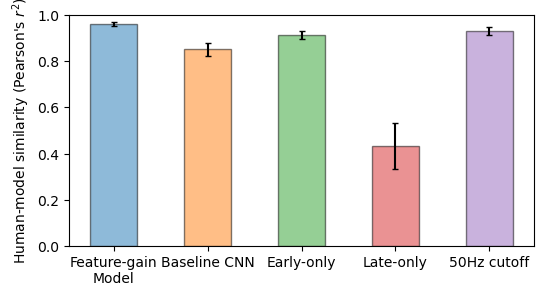

In [42]:

to_plot = model_agg_sim_df.sort_values('r', ascending=False)
# sort by model name 

model_order = util_analysis.model_name_order_w_50Hz

# sort to_plot based on group, according to model order
to_plot.sort_values('group', key=lambda x: x.map({model: i for i, model in enumerate(model_order)}), inplace=True)

# to_plot['group'] = pd.Categorical(to_plot['group'], categories=model_order, ordered=True)
to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)
## add bar plot 
fig, ax = plt.subplots(figsize=(aspect * 2, aspect))

bar_width = 0.5

for ix, row in to_plot.iterrows():
    y_err = np.array([row['r'] - row['r_ci'][0], row['r_ci'][1] - row['r']])
    y_err = y_err.reshape(2,-1)
    ax.bar(row['group'], row['r'], yerr=y_err, alpha=0.5, width=bar_width, edgecolor='k', capsize=2)
ax.set_ylim(0,1)
ax.set_ylabel("Human-model similarity (Pearson's $r^2$)", fontsize=fontsize)
# ax.set_xlabel("Model", fontsize=fontsize)
# 



In [43]:
### Get null distribution for statistical significance 

np.random.seed(0)

results_to_pool = combined_results[~combined_results.model.str.contains('alt')]
pooled_results = results_to_pool.melt(id_vars=['snr', 'background_condition', 'model'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
pooled_results['condition_str'] = pooled_results['snr'].astype(str) + ' dB ' + pooled_results['background_condition'] + ' ' + pooled_results['metric']


human_results = pooled_results[pooled_results.model.str.contains('Human')]
human_results = human_results.sort_values('condition_str')

model_list = [model for model in pooled_results.model.unique() if 'Human' not in model and 'Feature-gain main' not in model]


model_sim_records_pooled = []

n_boots = 10_000

## Get null dist 
def get_model_human_corr(human_results, model_results):
    ## Get Pearson's r ^ 2  and RMSE 
    r, p = stats.pearsonr(human_results.measure,  model_results.measure)
    r2 = r ** 2
    rmse = np.sqrt(np.mean((human_results.measure.values - model_results.measure.values)**2))
    return r2, rmse
    
def get_bootstrap_iter_result(model_str, results_df, human_results):
    # get data for comparison 
    model_results = results_df[results_df.model.isin([model_str, 'Feature-gain main'])].copy()
    model_names = model_results.model.values
    model_results['model'] = np.random.permutation(model_names) 
    model_a_data = model_results[model_results.model == model_str].sort_values('condition_str')
    model_b_data = model_results[model_results.model == 'Feature-gain main'].sort_values('condition_str')

    # get measures 
    model_a_r2, model_a_rmse = get_model_human_corr(human_results, model_a_data)
    model_b_r2, model_b_rmse = get_model_human_corr(human_results, model_b_data)

    # return diff of measures 
    diff_r2 = model_a_r2 - model_b_r2
    diff_rmse = model_a_rmse - model_b_rmse
    return diff_r2, diff_rmse


model_sim_diff_records = []
fba_result = pooled_results[pooled_results.model == 'Feature-gain main'].copy().sort_values('condition_str')

for model in tqdm(model_list):
    # get actual difference 
    model_result = pooled_results[pooled_results.model == model].copy().sort_values('condition_str')
    # get measures 
    fba_r2, fba_rmse = get_model_human_corr(human_results, fba_result)
    model_r2, model_rmse = get_model_human_corr(human_results, model_result)

    # return diff of measures 
    diff_r2 = fba_r2 - model_r2
    diff_rmse = fba_rmse - model_rmse

    r2_diff_dist = np.zeros(n_boots)
    rmse_diff_dist = np.zeros(n_boots)
    for ix in trange(n_boots, leave=False):
        r2_diff_dist[ix], rmse_diff_dist[ix] = get_bootstrap_iter_result(model, pooled_results, human_results)
    
    # get pvalue 
    p_r2 = (np.abs(r2_diff_dist) > np.abs(diff_r2)).mean()
    p_rmse = (np.abs(rmse_diff_dist) > np.abs(diff_rmse)).mean()
    model_sim_diff_records.append({
            'comparison': f'fba vs {model}',
            'true_r2_diff': diff_r2,
            'r2_pval': p_r2,
            'true_rmse_diff': diff_rmse,
            'rmse_pval': p_rmse,
    })

model_stim_agg_stats = pd.DataFrame.from_records(model_sim_diff_records)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:29<01:27, 29.24s/it]

  0%|          | 0/10000 [00:00<?, ?it/s]

 50%|█████     | 2/4 [00:58<00:58, 29.25s/it]

  0%|          | 0/10000 [00:00<?, ?it/s]

 75%|███████▌  | 3/4 [01:28<00:29, 29.38s/it]

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 4/4 [01:57<00:00, 29.40s/it]


In [27]:
model_stim_agg_stats

,comparison,true_r2_diff,r2_pval,true_rmse_diff,rmse_pval
0,fba vs Early-only,0.050689,0.0002,-0.059338,0.0000
1,fba vs 50Hz cutoff,0.032722,0.0061,-0.048176,0.0001
2,fba vs Late-only,0.527727,0.0000,-0.144942,0.0000
3,fba vs Baseline CNN,0.109906,0.0000,-0.089985,0.0000


In [44]:
def annot_stat(star, x1, x2, y, h, col='k', ax=None, lw=1.5):
    ax = plt.gca() if ax is None else ax
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=col)
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom', color=col)


def draw_stats_bar(ax, x1, x2, y, h, text, th=0.025, lw=1.5, col='k', fontsize=10, text_gap=0.02):
    # Calculate the position of the text
    text_x = (x1 + x2) * 0.5
    text_y = y + th
    
    # Calculate the gap around the text
    gap_half_width = text_gap * len(text) # * (x2 - x1) * 0.5
    
    # Draw the left part of the bar
    ax.plot([x1, x1, text_x - gap_half_width], [y, y + h, y + h], lw=lw, c=col)
    
    # Draw the right part of the bar
    ax.plot([text_x + gap_half_width, x2, x2], [y + h, y + h, y], lw=lw, c=col)
    
    # Draw the text in the middle of the bar
    ax.text(text_x, y+0.005, text, ha='center', va='center', color=col, fontsize=fontsize)
    

def get_star(p_val):
    if p_val < 0.05:
        text = "*"
    if p_val < 0.01:
        text = "**"
    if p_val < 0.001:
        text = "***"
    if p_val < 0.0001:
        text = "****"
    return text

### Same as above but now with stat annotations 

In [45]:
model_agg_sim_df.group.unique()

array(['Late-only', 'Early-only', 'Baseline CNN', '50Hz cutoff',
       'Feature-gain Model'], dtype=object)

## Version without 50Hz model

In [46]:
model_agg_sim_df.group.unique()

array(['Late-only', 'Early-only', 'Baseline CNN', '50Hz cutoff',
       'Feature-gain Model'], dtype=object)

In [47]:
sign_test_df

,model,r2_diff,r2_sign_test_stat,r2_sign_test_p,r2_diff_of_mean,rmse_diff,rmse_sign_test_stat,rmse_sign_test_p,rmse_diff_of_mean
0,Early-only,0.037283,5.0,0.001953,0.037283,-0.039329,-5.0,0.001953,-0.039329
1,Late-only,0.514321,5.0,0.001953,0.514321,-0.124933,-5.0,0.001953,-0.124933
2,Baseline CNN,0.096500,5.0,0.001953,0.096500,-0.069976,-5.0,0.001953,-0.069976
3,50Hz cutoff,0.019316,4.0,0.021484,0.019316,-0.028167,-5.0,0.001953,-0.028167


In [48]:
model_agg_sim_df

,group,r,r_ci,rmse,rmse_ci
0,Late-only,0.435354,"[0.33381927552152163, 0.5319395099982063]",0.219196,"[0.20272021397696963, 0.2373596866413151]"
1,Early-only,0.912392,"[0.8954578082117826, 0.9308893791009124]",0.133591,"[0.12094640227584541, 0.14663592884083695]"
2,Baseline CNN,0.853175,"[0.8249160767580002, 0.8811697245231697]",0.164239,"[0.14987771158079322, 0.1793583477322201]"
3,50Hz cutoff,0.930359,"[0.9120692438185533, 0.9467389441086631]",0.122430,"[0.11132069529149627, 0.13318462948528548]"
4,Feature-gain Model,0.963081,"[0.9522512286938118, 0.9716349358503918]",0.074254,"[0.0649262914277579, 0.08268248857937818]"


In [79]:
from copy import deepcopy
to_plot = model_agg_sim_df.copy()

model_order = deepcopy(util_analysis.model_name_order)

to_plot.sort_values('group', key=lambda x: x.map({model: i for i, model in enumerate(model_order)}), inplace=True)

model_order[0] = "Feature-gain\nModel"
to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)

x_vals = {model:ix for ix, model in enumerate(model_order)}
to_plot

/tmp/ipykernel_122802/2086919521.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)


,group,r,r_ci,rmse,rmse_ci
4,Feature-gain\nModel,0.963081,"[0.9522512286938118, 0.9716349358503918]",0.074254,"[0.0649262914277579, 0.08268248857937818]"
2,Baseline CNN,0.853175,"[0.8249160767580002, 0.8811697245231697]",0.164239,"[0.14987771158079322, 0.1793583477322201]"
1,Early-only,0.912392,"[0.8954578082117826, 0.9308893791009124]",0.133591,"[0.12094640227584541, 0.14663592884083695]"
0,Late-only,0.435354,"[0.33381927552152163, 0.5319395099982063]",0.219196,"[0.20272021397696963, 0.2373596866413151]"
3,50Hz cutoff,0.930359,"[0.9120692438185533, 0.9467389441086631]",0.122430,"[0.11132069529149627, 0.13318462948528548]"


/tmp/ipykernel_122802/3612512715.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)


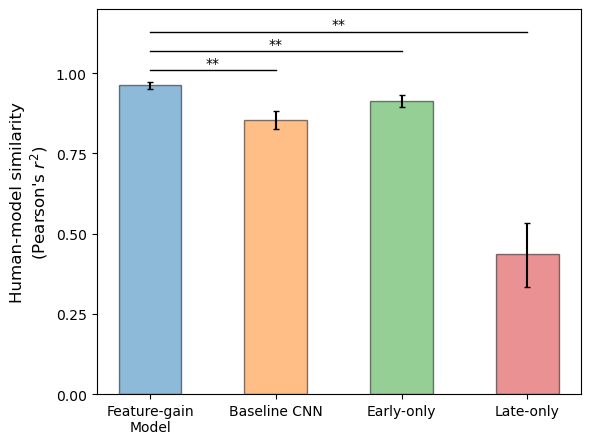

In [87]:
to_plot = model_agg_sim_df.copy()
## add bar plot 
aspect = 5
fig, ax = plt.subplots(figsize=(aspect*1.25, aspect))


model_order = deepcopy(util_analysis.model_name_order)

to_plot.sort_values('group', key=lambda x: x.map({model: i for i, model in enumerate(model_order)}), inplace=True)
model_order[0] = "Feature-gain\nModel"
to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)
# sort to_plot based on group, according to model order
x_vals = {model:ix for ix, model in enumerate(model_order)}

bar_width = 0.5

for ix, (_, row) in enumerate(to_plot.iterrows()):
    model = row['group']
    if model not in model_order:
        continue 
    y_err = np.array([row['r'] - row['r_ci'][0], row['r_ci'][1] - row['r']])
    y_err = y_err.reshape(2,-1)
    ax.bar(x_vals[model], row['r'], yerr=y_err, alpha=0.5, width=bar_width, edgecolor='k', capsize=2)
    # get pval 
    if model != 'Feature-gain\nModel':
        p_val = sign_test_df[sign_test_df.model == model].r2_sign_test_p.item()
        star = get_star(p_val)
        annot_stat(star, 0, x_vals[model], 0.95 + ix *.06, 0, ax=ax, lw=1)
        # draw_stats_bar(ax, 0, x_vals[model], 0.95 + ix *.05, .01, star, col='k', lw=0.75, fontsize=fontsize, text_gap=0.1)

ax.set_ylim(0,1.2)
ax.set_yticks(np.linspace(0,1,5))
# sns.despine()
ax.set_ylabel("Human-model similarity\n(Pearson's $r^2$)", fontsize=fontsize+2)
ax.set_xticks(np.arange(len(model_order)))
ax.set_xticklabels(model_order, fontsize=fontsize);




In [141]:
row.iloc[0]

group                             Feature-gain\nModel
r                                            0.963081
r_ci         [0.9534016657699566, 0.9719908373056821]
rmse                                         0.074254
rmse_ci    [0.06597381007156096, 0.08209769797726697]
Name: 0, dtype: object

/tmp/ipykernel_1354870/240999723.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  model_agg_sim_df['group'].replace("Feature-gain Model", "Feature-gain\nmodel", inplace=True)


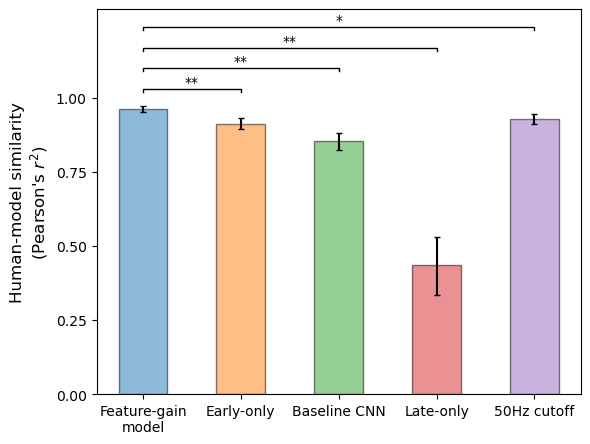

In [59]:
model_agg_sim_df = model_agg_sim_df.sort_values('r', ascending=False)
model_agg_sim_df['group'].replace("Feature-gain Model", "Feature-gain\nmodel", inplace=True)
## add bar plot 
aspect = 5
fig, ax = plt.subplots(figsize=(aspect*1.25, aspect))


models = ['Feature-gain\nmodel','Early-only', 'Baseline CNN', 'Late-only', '50Hz cutoff']

x_vals = {model:ix for ix, model in enumerate(models)}

bar_width = 0.5



for ix, model in enumerate(models):
    row = model_agg_sim_df[model_agg_sim_df.group == model].iloc[0]
    y_err = np.array([row['r'] - row['r_ci'][0], row['r_ci'][1] - row['r']])
    y_err = y_err.reshape(2,-1)
    ax.bar(x_vals[model], row['r'], yerr=y_err, alpha=0.5, width=bar_width, edgecolor='k', capsize=2)
    # get pval 
    if model != 'Feature-gain\nmodel':
        p_val = sign_test_df[sign_test_df.model == model].r2_sign_test_p.item()
        star = get_star(p_val)
        annot_stat(star, 0, x_vals[model], .95 + ix *.07, .01, ax=ax, lw=1)
        # draw_stats_bar(ax, 0, x_vals[model], 0.95 + ix *.05, .01, star, col='k', lw=0.75, fontsize=fontsize, text_gap=0.1)

ax.set_ylim(0,1.3)
ax.set_yticks(np.linspace(0,1,5))
# sns.despine()
ax.set_ylabel("Human-model similarity\n(Pearson's $r^2$)", fontsize=fontsize+2)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(models, fontsize=fontsize);




In [94]:
row

group                                     Late-only
r                                          0.435354
r_ci       [0.3305589119571876, 0.5257064523806975]
rmse                                       0.219196
rmse_ci     [0.202357288188559, 0.2355969515094241]
Name: 1, dtype: object

/tmp/ipykernel_2832227/3101557016.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
/tmp/ipykernel_2832227/3101557016.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')


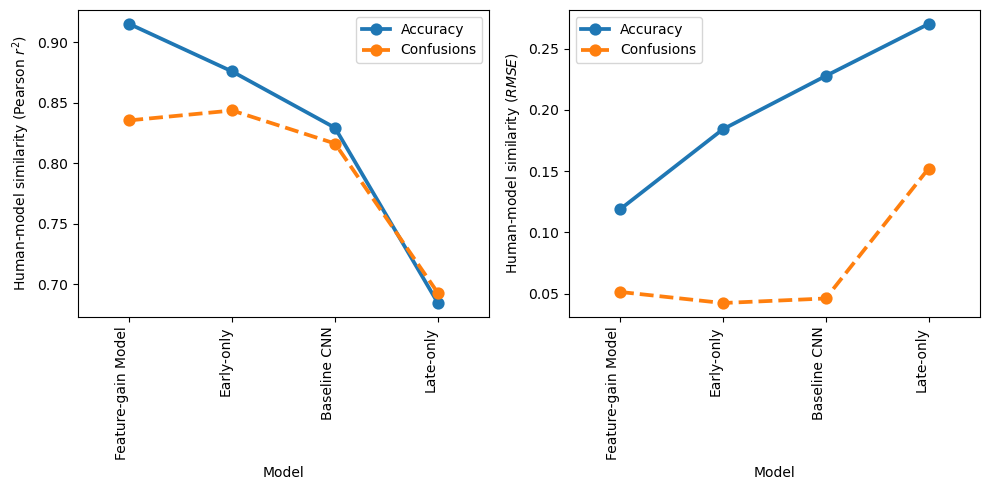

In [15]:
## Make double bar chart of r and RMSE
r_df = pd.DataFrame(model_r2_dict).T
rmse_df = pd.DataFrame(model_rmse_dict).T

fig, axs = plt.subplots(1,2, figsize=(10,5))

# x order is index sorted by r_df.accuracy 
order = r_df.accuracy.sort_values(ascending=False).index
r_df = r_df.loc[order]
# x_order = r_df.index

rmse_order = rmse_df.accuracy.sort_values(ascending=True).index
rmse_df = rmse_df.loc[rmse_order]



sns.pointplot(data=r_df, x=r_df.index, y=r_df.accuracy, ax=axs[0], linestyles='-', label='Accuracy')
sns.pointplot(data=r_df, x=r_df.index, y=r_df.confusions, ax=axs[0], linestyles='--', label='Confusions')

sns.pointplot(data=rmse_df, x=rmse_df.index, y=rmse_df.accuracy, ax=axs[1], linestyles='-', label='Accuracy')
sns.pointplot(data=rmse_df, x=rmse_df.index, y=rmse_df.confusions, ax=axs[1], linestyles='--', label='Confusions')

for ax in axs:
    # ax.set_ylim(0,1)
    ax.set_xlabel('Model')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')

axs[0].set_ylabel("Human-model similarity (Pearson $r^2$)")
axs[1].set_ylabel('Human-model similarity ($RMSE$)')
# axs[0].set_title('Task-Accuracy')
# axs[0].set_title('Task-Confusions')
plt.tight_layout()
